In [1]:
# notebook for testing out new TJ river flow maker...
import sys
import os
import subprocess
import shutil
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import gsw
import pickle
import glob
import urllib.request
from urllib.error import URLError, HTTPError


from datetime import datetime, timedelta, date

sys.path.append('../sdpm_py_util')
import init_funs_forecast as initfuns
import run_funs as runfuns
import util_functions as utilfuns
import river_functions as riverfuns
import ocn_funs_forecast as ocnfuns
import swan_functions as swanfuns
import run_funs as runfuns
sys.path.append('/home/mspydell/models/PFM_root/PFM/driver')
import driver_functions as driverfuns
#from driver_run_forecast_LV1234 import driver_run_fore_LV1234
from driver_run_pfm_phm import driver_run_pfm_phm


/home/mspydell/models/PFM_root/PFM/ipynb_files/../sdpm_py_util/ocn_functions.py:32: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater


<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    type: atmospheric forcing file fields for surface fluxes
    time info: ocean time is from 1999/01/01 00:00:00
    coordinates: lat lon ocean_time
    dimensions(sizes): tair_time(101), er(1141), xr(486), pair_time(101), qair_time(101), wind_time(101), rain_time(102), srf_time(102), lrf_time(102), time(101)
    variables(dimensions): float64 Tair(tair_time, er, xr), float64 Pair(pair_time, er, xr), float64 Qair(qair_time, er, xr), float64 Uwind(wind_time, er, xr), float64 Vwind(wind_time, er, xr), float64 rain(rain_time, er, xr), float64 swrad(srf_time, er, xr), float64 lwrad(lrf_time, er, xr), float64 lwrad_down(lrf_time, er, xr), float64 lat(er, xr), float64 lon(er, xr), float64 ocean_time(time), float64 tair_time(tair_time), float64 pair_time(pair_time), float64 qair_time(qair_time), float64 wind_time(wind_time), float64 rain_time(rain_time), float64 srf_time(srf_time), float64 lrf_time(lrf_time)
    gr

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    history: Wed Oct  8 01:59:27 2025: ncks -q -D 0 -v waveTime,waveHs,waveTp,waveDp,waveFrequency,waveDirection,waveDirectionalSpectrum,metaLatitude,metaLongitude https://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/model/misc/falk/forecast/F1001_ecmwf_fc.nc -4 -O /scratch/PFM_Simulations/cdip_data/cdip_1001_2025100800.nc
2025-10-08T03:40:13Z: dataset created; Net_model version 2.1. Runtime arguments: /project/f90_bin/net_model_gf -s 202510071500 -h 192 -g 1 -c Falk_LV4_trim_refs.nc -i ECMWF_forecast.INPUT -z ecmwf_fc -S -2 -b datawell_trim If date_modified is after date_created, contact CDIP for details of changes.
    date_created: 2025-10-08T03:40:13Z
    date_modified: 2025-10-08T03:40:13Z
    title: Bulk wave parameters and directional wave spectra as predicted by the CDIP MOP version 1.1 model for the sites defined in F1001.
    summary: The CDIP Monitoring and Prediction (MOP) System output of spectral wav

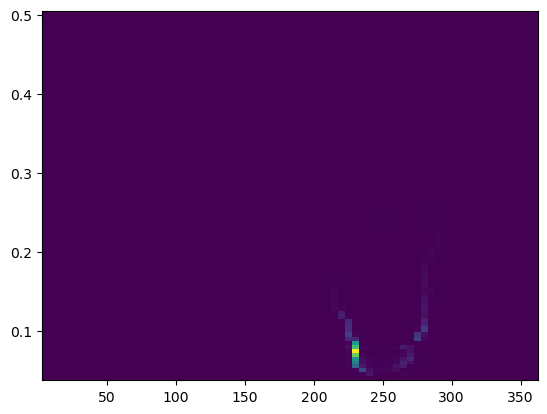

In [8]:
fn = '/scratch/PFM_Simulations/cdip_data/cdip_1001_2025100800.nc'
ds = nc.Dataset(fn)
print(ds)

theta = ds.variables['waveDirection'][:].data
freq = ds.variables['waveFrequency'][:].data
time = ds.variables['waveTime'][:].data
Spp = ds.variables['waveDirectionalSpectrum'][:].data

fig, ax = plt.subplots()
plt.pcolormesh(theta, freq, Spp[0,:,:])



In [ ]:

info_pkl="/scratch/matt/PFM_Simulations_v2/forecast_info.pkl"
driverfuns.run_fore_LV4(info_pkl)

In [ ]:
def file_url_exists(url):
    """
    Checks if a file at the given URL exists and is accessible.

    Args:
        url (str): The URL of the file to check.

    Returns:
        bool: True if the file exists and is accessible (returns a 200, 301, or 302 status code), 
              False otherwise.
    """
    try:
        # Create a Request object and set the method to 'HEAD'
        req = urllib.request.Request(url, method='HEAD')
        
        # Open the URL and get the response
        with urllib.request.urlopen(req) as response:
            # Check for successful status codes (200 OK, 301 Moved Permanently, 302 Found)
            return response.getcode() in (200, 301, 302)
    except HTTPError as e:
        # Handle HTTP errors (e.g., 404 Not Found, 403 Forbidden)
        print(f"HTTP Error for {url}: {e.code} - {e.reason}")
        return False
    except URLError as e:
        # Handle URL errors (e.g., network issues, invalid URL)
        print(f"URL Error for {url}: {e.reason}")
        return False
    except Exception as e:
        # Catch any other unexpected errors
        print(f"An unexpected error occurred for {url}: {e}")
        return False
    

In [ ]:
fore_type = 'medium_range_blend' # short_range, long_range, etc.
nhr = 24 * 5
hrs = 1 + np.arange(0,nhr+3,1) # data is at 1 hr intervals, we will loop through this to get the data...
                                            # the +3 here is to get 2 extra hours of data. this is needed to get riv.nc 
                                            # to work correctly.
yyyymmdd = '20250924'
hh = '18'
url = 'https://nomads.ncep.noaa.gov/pub/data/nccf/com/nwm/v3.0/nwm.' + yyyymmdd + '/' + fore_type
fname = ['nwm.t','z.'+fore_type+'.channel_rt.f','.conus.nc']
#nwm.t00z.medium_range_blend.channel_rt.f001.conus.nc
hr=1
hr_str = str(int(hr)).zfill(3)
fn = fname[0] + hh + fname[1] + hr_str + fname[2]
url_tot = url + '/' + fn

rc = file_url_exists(url_tot)
print(rc)

HTTP Error for https://nomads.ncep.noaa.gov/pub/data/nccf/com/nwm/v3.0/nwm.20250924/medium_range_blend/nwm.t18z.medium_range_blend.channel_rt.f001.conus.nc: 404 - Not Found
False


: 

In [ ]:
pkl_fnm="/scratch/PHM_Simulations/phm_info.pkl"
PFM = initfuns.get_model_info(pkl_fnm)
initfuns.remove_swan_rst_nohour(pkl_fnm)


going to deleting swan base rst files...
deleting some files...


: 

In [3]:
fn = '/dataSIO/PFM_Simulations/Archive/Forcing/river_LV4_2025031800.nc'
ds_atm = nc.Dataset(fn)
print(ds_atm.variables['river_transport'][1:10,:])

[[-0.80799998 -0.80799998 -0.80799998 -0.80799998 -0.80799998 -2.1906
  -1.45999997 -1.45999997 -1.24999997]
 [-0.80399998 -0.80399998 -0.80399998 -0.80399998 -0.80399998 -2.1906
  -1.45999997 -1.45999997 -1.24999997]
 [-0.79999998 -0.79999998 -0.79999998 -0.79999998 -0.79999998 -2.1906
  -1.45999997 -1.45999997 -1.24999997]
 [-0.79999998 -0.79999998 -0.79999998 -0.79999998 -0.79999998 -2.1906
  -1.49999997 -1.49999997 -1.24999997]
 [-0.80599998 -0.80599998 -0.80599998 -0.80599998 -0.80599998 -2.1906
  -1.57999996 -1.57999996 -1.25999997]
 [-0.81799998 -0.81799998 -0.81799998 -0.81799998 -0.81799998 -2.1906
  -1.64999996 -1.64999996 -1.26999997]
 [-0.83399998 -0.83399998 -0.83399998 -0.83399998 -0.83399998 -2.1906
  -1.68499996 -1.68499996 -1.27999997]
 [-0.84799998 -0.84799998 -0.84799998 -0.84799998 -0.84799998 -2.1906
  -1.69499996 -1.69499996 -1.28999997]
 [-0.85799998 -0.85799998 -0.85799998 -0.85799998 -0.85799998 -2.1906
  -1.67999996 -1.67999996 -1.28999997]]


In [ ]:


f_names = glob.glob(PFM['restart_files_dir'] + '/LV4*_???.dat*')
t_hind = datetime(2024,10,12)
for fn in f_names:
    t_fn = datetime.strptime(fn[-24:-16],'%Y%m%d')
    if t_fn <= t_hind - 3*timedelta(days=1):
        print('need to remove file!')


In [2]:
fore_pkl_fnm = '/scratch/PFM_Simulations/forecast_info.pkl'
ret = utilfuns.make_web_nc_file(fore_pkl_fnm)
print(ret)

making the web_essential.nc file...
going to copy  /scratch/PFM_Simulations/LV4_Forecast/His/web_data_2025091500.nc  to
/dataSIO/PFM_Simulations/Archive/for_web/web_data_latest.nc  and  /dataSIO/PFM_Simulations/Archive/web/web_data_2025091500.nc
done copying to /for_web/.
done copying to /web/
CompletedProcess(args=['python', '-W', 'ignore', 'web_functions.py', 'full_his_to_essential', '/scratch/PFM_Simulations/LV4_Forecast/His/LV4_ocean_his_202509150000.nc', '/scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV4_mss_oct2024.nc', '/scratch/PFM_Simulations/forecast_info.pkl'], returncode=0)


In [4]:
in_py="/home/mspydell/models/PFM_root/PFM/sdpm_py_util/phm_model_info_devel_wLV4.py"
pkl_fnm="/scratch/PHM_Simulations/phm_info.pkl"

#initfuns.initialize_model( in_py, pkl_fnm )
os.chdir('../sdpm_py_util')
runfuns.make_LV4_coawst_dotins_dotsb(pkl_fnm,'hind')
runfuns.run_slurm_LV4(pkl_fnm, 'hind')


for this LV4 simulation
the grid file used is:
/scratch/PFM_Simulations/Grids/GRID_SDTJRE_LV4_mss_oct2024.nc
history file made will be:
/scratch/PHM_Simulations/LV4_Forecast/His/LV4_ocean_his_202410120000.nc
restart file made will be:
/scratch/PHM_Simulations/restart_data/LV4_ocean_rst_202410120000_202410130000.nc
the ini file used is:
/scratch/PHM_Simulations/LV4_Forecast/Forc/LV4_OCEAN_IC.nc
the river input file is:
/scratch/PHM_Simulations/LV4_Forecast/Forc/river_20241011_20241012.nc
we are using
/scratch/PFM_Simulations/executables/coawstM_intel
starting the background process that looks for modified swan restart files
we check for modified files every 144 s (wall time)
run_slurm_LV4: current directory is now:  /scratch/PHM_Simulations/LV4_Forecast/Run


Traceback (most recent call last):
  File "/home/mspydell/models/PFM_root/PFM/sdpm_py_util/swan_functions.py", line 545, in <module>
    globals()[args[1]](*args[2:])    
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mspydell/models/PFM_root/PFM/sdpm_py_util/swan_functions.py", line 517, in check_and_move
    time.sleep(dt_sec)  # Check every dt_sec second
    ^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [2]:
pkl_fnm="/scratch/PFM_Simulations/forecast_info.pkl"
utilfuns.copy_mv_nc_file_v2('atm','lv4',pkl_fnm)
utilfuns.copy_mv_nc_file_v2('river','lv4',pkl_fnm)


In [3]:
MI = initfuns.get_model_info(pkl_fnm)
fout = MI['lv4_forc_dir'] + '/' + MI['lv4_swan_bnd_file']
print(fout)
fout = MI['lv4_forc_dir'] + '/' + MI['lv4_swan_wnd_file']
print(fout)

/scratch/PHM_Simulations/LV4_Forecast/Forc/LV4_swan.bnd
/scratch/PHM_Simulations/LV4_Forecast/Forc/LV4_swan.wnd


In [4]:
t1=datetime.now()
print('driver_run_forcast_LV4: making swan bnd and wnd files...')
os.chdir('../sdpm_py_util')
cmd_list = ['python','-u','-W','ignore','swan_functions.py','cdip_ncs_to_dict_hind',pkl_fnm]
ret1 = subprocess.run(cmd_list)   
print('cdip to dictionary return code: ' + str(ret1.returncode) + ' (0=good)')  
fout = MI['lv4_forc_dir'] + '/' + MI['lv4_swan_bnd_file']
print('making swan .bnd file...')
cmd_list = ['python','-u','-W','ignore','swan_functions.py','mk_swan_bnd_file',fout,pkl_fnm]
ret2 = subprocess.run(cmd_list)   
print('...done. swan bnd file return code: ' + str(ret2.returncode) + ' (0=good)')  
fout = MI['lv4_forc_dir'] + '/' + MI['lv4_swan_wnd_file']
print('making swan wnd file...')
cmd_list = ['python','-u','-W','ignore','swan_functions.py','mk_swan_wnd_file',fout,pkl_fnm]
ret3 = subprocess.run(cmd_list)   
print('...done. swan wnd file return code: ' + str(ret3.returncode) + ' (0=good)')  
t2 = datetime.now()


driver_run_forcast_LV4: making swan bnd and wnd files...
Now making dictionary of cdip data...
...done.

CDIP data saved as pickle file
cdip to dictionary return code: 0 (0=good)
making swan .bnd file...

CDIP pickle file loaded
...done. swan bnd file return code: 0 (0=good)
making swan wnd file...
...done. swan wnd file return code: 0 (0=good)


In [ ]:


t1str =  MI['start_times_str'][0]
level = 4
t1 = datetime.strptime(t1str,'%Y%m%d%H')
t2 = t1 + MI['forecast_days']*timedelta(days=1)
t2str = t2.strftime('%Y%m%d%H')
# now for the atm part... this function is different from MI
dt_download_atm = []
print('we are now getting the atm data...')
t01 = datetime.now()
cmd_list = ['python','-W','ignore','hind_functions.py','get_nam_hindcast_grb2s_v2',t1str,t2str,pkl_fnm]
os.chdir('../sdpm_py_util')
ret5 = subprocess.run(cmd_list)   
print('return code: ' + str(ret5.returncode) + ' (0=good)')  
os.chdir('../sdpm_py_util')
print('...done.')
t02 = datetime.now()
print('this took:')
print(t02-t01)
print('\n')
dt_download_atm.append(t02-t01)

print('we are now converting the atm grb2 files to pickles...')
t01 = datetime.now()
cmd_list = ['python','-W','ignore','hind_functions.py','grb2s_to_pickles',t1str,t2str,pkl_fnm]
os.chdir('../sdpm_py_util')
ret5 = subprocess.run(cmd_list)   
print('return code: ' + str(ret5.returncode) + ' (0=good)')  
os.chdir('../sdpm_py_util')
print('...done.')
t02 = datetime.now()
print('this took:')
print(t02-t01)
print('\n')

print('we are now putting the hind atm data on the roms LV4 grid...')
t01 = datetime.now()
cmd_list = ['python','-W','ignore','hind_functions.py','nam_pkls_2_romsatm_pkl',t1str,t2str,str(level),pkl_fnm]
os.chdir('../sdpm_py_util')
ret5 = subprocess.run(cmd_list)   
print('return code: ' + str(ret5.returncode) + ' (0=good)')  
os.chdir('../sdpm_py_util')
print('...done.')
# all the fields plotted with the data on roms grid
t02 = datetime.now()
print('this took:')
print(t02-t01)
print('\n')
dt_atm = []
dt_atm.append(t02-t01)

# fn_out is the name of the atm.nc file used by roms
fn_atm_out = MI['lv4_forc_dir'] + '/' + MI['lv4_atm_file'] # LV1 atm forcing filename
print('we are now saving ATM LV4 to ' + fn_atm_out + ' ...')
t01 = datetime.now()
cmd_list = ['python','-W','ignore','atm_functions.py','atm_roms_dict_to_netcdf',str(level),pkl_fnm,'hind']
os.chdir('../sdpm_py_util')
ret5 = subprocess.run(cmd_list)   
print('return code: ' + str(ret5.returncode) + ' (0=good)')  
os.chdir('../sdpm_py_util')
print('...done.') 
# put in a function to plot the atm.nc file if we want to
t02 = datetime.now()
print('this took:')
print(t02-t01)
print('\n')
dt_atm.append(t02-t01)


we are now getting the atm data...
the  9  grb2 files already exist, no need to download.
return code: 0 (0=good)
...done.
this took:
0:00:00.793033


we are now converting the atm grb2 files to pickles...
ATM grb2 file /dataSIO/PHM_Simulations/raw_download/nam_grb2/nam_218_20241011_0000_000.grb2 saved to pickle.
ATM grb2 file /dataSIO/PHM_Simulations/raw_download/nam_grb2/nam_218_20241011_0000_003.grb2 saved to pickle.
ATM grb2 file /dataSIO/PHM_Simulations/raw_download/nam_grb2/nam_218_20241011_0600_000.grb2 saved to pickle.
ATM grb2 file /dataSIO/PHM_Simulations/raw_download/nam_grb2/nam_218_20241011_0600_003.grb2 saved to pickle.
ATM grb2 file /dataSIO/PHM_Simulations/raw_download/nam_grb2/nam_218_20241011_1200_000.grb2 saved to pickle.
ATM grb2 file /dataSIO/PHM_Simulations/raw_download/nam_grb2/nam_218_20241011_1200_003.grb2 saved to pickle.
ATM grb2 file /dataSIO/PHM_Simulations/raw_download/nam_grb2/nam_218_20241011_1800_000.grb2 saved to pickle.
ATM grb2 file /dataSIO/PHM_Simu

In [4]:
fn = '/scratch/PHM_Simulations/LV4_Forecast/Forc/LV4_ATM_FORCING.nc'
ds_atm = nc.Dataset(fn)
print(ds_atm)

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    type: atmospheric forcing file fields for surface fluxes
    time info: ocean time is from 1999/01/01 00:00:00
    coordinates: lat lon ocean_time
    dimensions(sizes): tair_time(9), er(1141), xr(486), pair_time(9), qair_time(9), wind_time(9), rain_time(9), srf_time(9), lrf_time(9), time(9)
    variables(dimensions): float64 Tair(tair_time, er, xr), float64 Pair(pair_time, er, xr), float64 Qair(qair_time, er, xr), float64 Uwind(wind_time, er, xr), float64 Vwind(wind_time, er, xr), float64 rain(rain_time, er, xr), float64 swrad(srf_time, er, xr), float64 lwrad(lrf_time, er, xr), float64 lwrad_down(lrf_time, er, xr), float64 lat(er, xr), float64 lon(er, xr), float64 ocean_time(time), float64 tair_time(tair_time), float64 pair_time(pair_time), float64 qair_time(qair_time), float64 wind_time(wind_time), float64 rain_time(rain_time), float64 srf_time(srf_time), float64 lrf_time(lrf_time)
    groups: 


the river file .nc file name for this LV4 hindcast is...
/scratch/PHM_Simulations/LV4_Forecast/Forc/river_20241011_20241012.nc
checking to see if this file exists...
'/scratch/PHM_Simulations/LV4_Forecast/Forc/river_20241011_20241012.nc' does not exist. Need to make...
making the dictionary first...
the raw tj river discharge is in the file  /dataSIO/PHM_Simulations/raw_download/qtj_obs_data/qtj_raw_20200101_20250901.csv
check and see if this file has the data...
'/dataSIO/PHM_Simulations/raw_download/qtj_obs_data/qtj_raw_20200101_20250901.csv' exists. Checking to see if the data in it covers the time range:
'2024-10-03 23:45:00' to '2024-10-19 00:15:00'
'/dataSIO/PHM_Simulations/raw_download/qtj_obs_data/qtj_raw_20200101_20250901.csv' has the data we need. Retrieving it from the file...
/dataSIO/PHM_Simulations/raw_download/nwm_files/nwm_assim_20241010.nc  exists. No need to download.
/dataSIO/PHM_Simulations/raw_download/nwm_files/nwm_assim_20241011.nc  exists. No need to download.
/

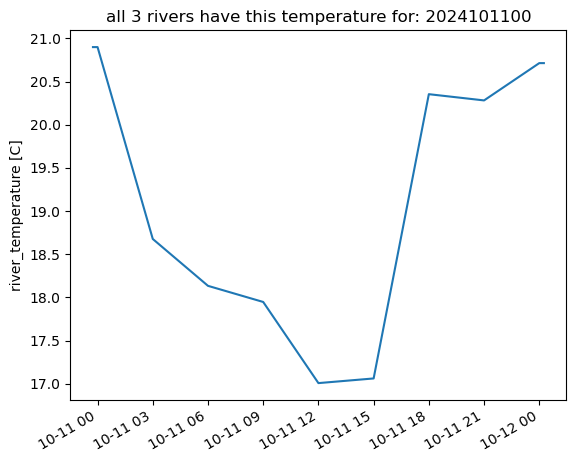

In [3]:

ocnfuns.mk_lv4_hind_river_nc(pkl_fnm)


In [ ]:

t0 = datetime(2024,10,11)
nday  = 1   
t2 = t0 + nday * timedelta(days=1)
dt_riv = timedelta(minutes=15) # this is the dt for the river file
t_riv = np.arange(t0-dt_riv,t2+2*dt_riv,dt_riv)

fn_dates = riverfuns.get_nwm_dates_for_simulation(t_riv)
print(fn_dates)

nwm_dir = '/dataSIO/PHM_Simulations/raw_download/nwm_files/'

# now check to see if the nwm_dir has these files...
riverfuns.check_for_nwm_raw_files(nwm_dir,fn_dates)


<class 'numpy.datetime64'>
['/dataSIO/PHM_Simulations/raw_download/nwm_files/nwm_assim_20241010.nc', '/dataSIO/PHM_Simulations/raw_download/nwm_files/nwm_assim_20241011.nc', '/dataSIO/PHM_Simulations/raw_download/nwm_files/nwm_assim_20241012.nc']


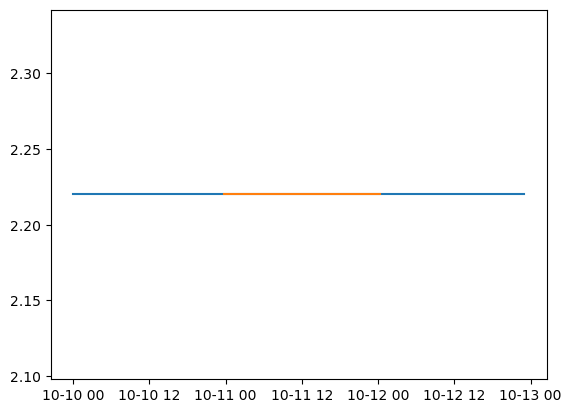

In [ ]:
print(type(t_riv[0]))

# these are the reach ids that are in the .nc files
reach_ids = [948070199, 20331702, 20324441]
#location_names = ['SW','Otay','TJR']
reach_ids = np.array(reach_ids)

file_names = riverfuns.get_nwm_file_names(nwm_dir,fn_dates)

t_nc,q_nc,rid_nc = riverfuns.get_data_from_nwm_nc_files(file_names)
t_nc64 = t_nc.astype('datetime64[D]')

i_sw = np.argwhere(rid_nc == reach_ids[0])
i_om = np.argwhere(rid_nc == reach_ids[1])

q_sw = np.squeeze(q_nc[:,i_sw])
q_om = np.squeeze(q_nc[:,i_om])

qi_sw = np.interp(t_riv.astype('int'),t_nc64.astype('int'),q_sw)
qi_om = np.interp(t_riv.astype('int'),t_nc64.astype('int'),q_om)

fig, ax = plt.subplots()
ax.plot(t_nc,q_nc[:,2])
ax.plot(t_riv,qi_sw)


In [21]:
fn= '/dataSIO/PFM_Simulations/Archive/Forcing/river_LV4_2025030200.nc'
ds = nc.Dataset(fn)
print(ds)
print(ds.variables['river_transport'][1:5,:])
print(ds.variables['river_dye_01'][1:5,-1,:])
print(ds.variables['river_dye_02'][1:5,-1,:])

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    type: river and tracer file for roms PFM
    author: matthew spydell
    note: similar to XWu river_tracer.nc file.
    dimensions(sizes): river(9), s_rho(10), river_time(51)
    variables(dimensions): float64 theta_s(), float64 theta_b(), float64 Tcline(), float64 hc(), float64 river(river), int64 river_Xposition(river), int64 river_Eposition(river), int64 river_direction(river), float64 river_flag(river), float64 river_Vshape(s_rho, river), float64 river_transport(river_time, river), float64 river_temp(river_time, s_rho, river), float64 river_salt(river_time, s_rho, river), float64 river_dye_01(river_time, s_rho, river), float64 river_dye_02(river_time, s_rho, river), float64 Cs_r(s_rho), float64 river_time(river_time)
    groups: 
[[-0.22399999 -0.22399999 -0.22399999 -0.22399999 -0.22399999 -2.1906
  -1.07499998 -1.07499998 -1.12999997]
 [-0.22399999 -0.22399999 -0.22399999 -0.22399999 -0.22399999 -2.1

In [22]:
fn= '/dataSIO/PFM_Simulations/Archive/Forcing/river_LV4_2025090900.nc'
ds = nc.Dataset(fn)
print(ds)
print(ds.variables['river_transport'][1:5,:])
print(ds.variables['river_dye_01'][1:5,-1,:])
print(ds.variables['river_dye_02'][1:5,-1,:])

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    type: river and tracer file for roms PFM
    author: matthew spydell
    note: similar to XWu river_tracer.nc file.
    dimensions(sizes): river(9), s_rho(10), river_time(123)
    variables(dimensions): float64 theta_s(), float64 theta_b(), float64 Tcline(), float64 hc(), float64 river(river), int64 river_Xposition(river), int64 river_Eposition(river), int64 river_direction(river), float64 river_flag(river), float64 river_Vshape(s_rho, river), float64 river_transport(river_time, river), float64 river_temp(river_time, s_rho, river), float64 river_salt(river_time, s_rho, river), float64 river_dye_01(river_time, s_rho, river), float64 river_dye_02(river_time, s_rho, river), float64 Cs_r(s_rho), float64 river_time(river_time)
    groups: 
[[-0.03848895 -0.03848895 -0.03848895 -0.03848895 -0.03848895 -2.
  -0.91499998 -0.91499998 -0.76999998]
 [-0.03841875 -0.03841875 -0.03841875 -0.03841875 -0.03841875 -2.
  -

In [ ]:

pkl_fnm = "/scratch/PFM_Simulations/forecast_info.pkl"
t0 = datetime(2024,10,11)
nday = 1
t1_str = (t0 - 1 * timedelta(days = 1)).strftime('%Y%m%d%H')
t2_str = (t0 + nday * timedelta(days = 1) + 1 * timedelta(days = 1)).strftime('%Y%m%d%H') 
t_tj, q_tj = riverfuns.get_tj_observed_flow(t1_str,t2_str,pkl_fnm)


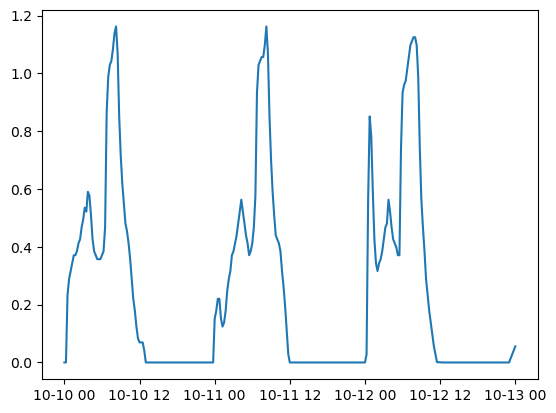

In [ ]:
fig, ax = plt.subplots()
ax.plot(t_tj,q_tj)



In [2]:
fore_t0 = datetime(2024,10,11)
fore_hr = 1
date_str = fore_t0.strftime('%Y%m%d')
fore_hr_str = str(fore_hr).zfill(3)
url = 'https://storage.googleapis.com/national-water-model/nwm.' + \
    date_str + \
    '/medium_range_blend/nwm.t00z.medium_range_blend.channel_rt.f' + \
    fore_hr_str + \
    '.conus.nc#mode=bytes'

url = 'https://storage.googleapis.com/national-water-model/nwm.20241011/analysis_assim/nwm.t00z.analysis_assim.channel_rt.tm00.conus.nc#mode=bytes'

# t01z is the hour, goes up to t23z
# m01 is the previous hour



print(url)
ds = nc.Dataset(url)
print(ds)



https://storage.googleapis.com/national-water-model/nwm.20241011/analysis_assim/nwm.t00z.analysis_assim.channel_rt.tm00.conus.nc#mode=bytes
<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    TITLE: OUTPUT FROM NWM v3.0
    featureType: timeSeries
    proj4: +proj=lcc +units=m +a=6370000.0 +b=6370000.0 +lat_1=30.0 +lat_2=60.0 +lat_0=40.0 +lon_0=-97.0 +x_0=0 +y_0=0 +k_0=1.0 +nadgrids=@
    model_initialization_time: 2024-10-10_21:00:00
    station_dimension: feature_id
    model_output_valid_time: 2024-10-11_00:00:00
    model_total_valid_times: 3
    stream_order_output: 1
    cdm_datatype: Station
    Conventions: CF-1.6
    code_version: v5.3.0-alpha1
    NWM_version_number: v3.0
    model_output_type: channel_rt
    model_configuration: analysis_and_assimilation
    dev_OVRTSWCRT: 1
    dev_NOAH_TIMESTEP: 3600
    dev_channel_only: 0
    dev_channelBucket_only: 0
    dev: dev_ prefix indicates development/internal meta data
    dimensions(sizes): feature

In [14]:
id = ds.variables['feature_id'][:]
t =  ds.variables['time']
q = ds.variables
date2 = nc.num2date(t[:],t.units).data
std_dt = datetime.strptime(date2[0].isoformat(), "%Y-%m-%dT%H:%M:%S")
print(std_dt)

reach_ids = [948070199, 20331702, 20324441]
            #SW         Otay      TJR 20324441 is last segment near ocean.
reach_ids = np.array(reach_ids)
mask_val1 = (id == reach_ids[0])
mask_val2 = (id == reach_ids[1])
mask_val3 = (id == reach_ids[2])

# Combine the masks using logical OR
combined_mask = mask_val1 | mask_val2 | mask_val3

# Get the indices where the combined mask is True
ig = np.where(combined_mask)
# the ordering of ig is: TJ, Otay, SW - it got reversed 

qq = ds.variables['streamflow'][ig]
qq2 = ds.variables['streamflow'][ig]

q3 = np.zeros((2,3))
q3[0,:] = qq
q3[1,:] = qq2

reach_ids_2 = id[ig]

print(qq)
print(reach_ids_2)
print(q3)




2024-10-11 00:00:00
[0.49999999 1.37999997 2.21999995]
[ 20324441  20331702 948070199]
[[0.49999999 1.37999997 2.21999995]
 [0.49999999 1.37999997 2.21999995]]


In [ ]:

reach_ids = [948070199, 20331702, 20324441]
            #SW         Otay      TJR 20324441 is last segment near ocean.
reach_ids = np.array(reach_ids)
mask_val1 = (id == reach_ids[0])
mask_val2 = (id == reach_ids[1])
mask_val3 = (id == reach_ids[2])

# Combine the masks using logical OR
combined_mask = mask_val1 | mask_val2 | mask_val3

# Get the indices where the combined mask is True
ig = np.where(combined_mask)
# the ordering of ig is: TJ, Otay, SW - it got reversed 


print(ig)
qq = ds.variables['streamflow'][ig]
print(qq)
print(id[ig])
print(t3)



In [ ]:
t1 = datetime(2024,10,10,23,0,0)
t2 = datetime(2024,10,12,1,0,0)
urls = riverfuns.get_hind_nwm_urls(t1,t2)
print(urls)



['https://storage.googleapis.com/national-water-model/nwm.20241010analysis_assim/nwm.t23z.analysis_assim.channel_rt.tm00.conus.nc#mode=bytes', 'https://storage.googleapis.com/national-water-model/nwm.20241011analysis_assim/nwm.t00z.analysis_assim.channel_rt.tm00.conus.nc#mode=bytes', 'https://storage.googleapis.com/national-water-model/nwm.20241011analysis_assim/nwm.t01z.analysis_assim.channel_rt.tm00.conus.nc#mode=bytes', 'https://storage.googleapis.com/national-water-model/nwm.20241011analysis_assim/nwm.t02z.analysis_assim.channel_rt.tm00.conus.nc#mode=bytes', 'https://storage.googleapis.com/national-water-model/nwm.20241011analysis_assim/nwm.t03z.analysis_assim.channel_rt.tm00.conus.nc#mode=bytes', 'https://storage.googleapis.com/national-water-model/nwm.20241011analysis_assim/nwm.t04z.analysis_assim.channel_rt.tm00.conus.nc#mode=bytes', 'https://storage.googleapis.com/national-water-model/nwm.20241011analysis_assim/nwm.t05z.analysis_assim.channel_rt.tm00.conus.nc#mode=bytes', 'http

In [ ]:
t0 = datetime(2024,10,11)
nday = 1
t1_str = t0.strftime('%Y%m%d%H') # hindcast begin time UTC
t2_str = (t0 + nday * timedelta(days=1)).strftime('%Y%m%d%H') # hindcast end time UTC
t,q = riverfuns.get_nwm_analysis_flow(t1_str,t2_str)

print(t)
print(q)


(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116132, 2117200, 2712470]),)
(array([2116

In [ ]:
t1 = datetime(2020,1,1)
t2 = datetime(2025,9,1)
file_out = '/dataSIO/PHM_Simulations/raw_download/qtj_obs_data/qtj_raw_20200101_20250901.csv'
t1_str = t1.strftime('%Y-%m-%d')
t2_str = t2.strftime('%Y-%m-%d')
riverfuns.make_obs_Qtj_file(t1_str,t2_str,file_out)    



File downloaded successfully: /dataSIO/PHM_Simulations/raw_download/qtj_obs_data/qtj_raw_20200101_20250901.csv


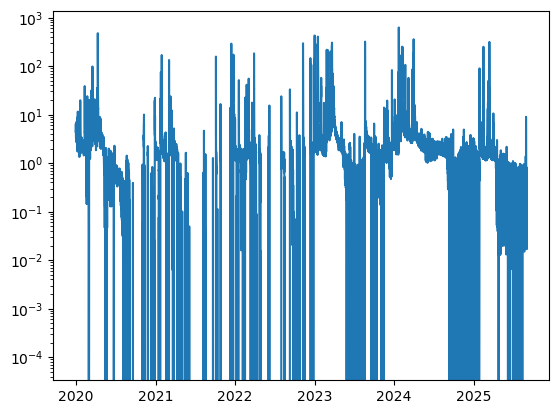

In [ ]:
t_tj_raw, q_tj_raw = riverfuns.get_all_tj_observed_data(file_out)
fig, ax = plt.subplots()
ax.plot(t_tj_raw,q_tj_raw)
plt.yscale('log')


In [2]:
t0 = datetime(2024,10,11)
nday  = 1   
t2 = t0 + nday * timedelta(days=1)
dt_riv = timedelta(minutes=15) # this is the dt for the river file
t_riv = np.arange(t0-dt_riv,t2+2*dt_riv,dt_riv)
#fn_qtj = PFM['qtj_obs_fname_full']
info_pkl="/scratch/PHM_Simulations/phm_info.pkl"
q_tj = riverfuns.get_tj_observed_flow(t_riv,info_pkl,'raw_interp')



the raw tj river discharge is in the file  /dataSIO/PHM_Simulations/raw_download/qtj_obs_data/qtj_raw_20200101_20250901.csv
check and see if this file has the data...
'/dataSIO/PHM_Simulations/raw_download/qtj_obs_data/qtj_raw_20200101_20250901.csv' exists. Checking to see if the data in it covers the time range:
'2024-10-03 23:45:00' to '2024-10-19 00:15:00'
'/dataSIO/PHM_Simulations/raw_download/qtj_obs_data/qtj_raw_20200101_20250901.csv' has the data we need. Retrieving it...


2024-10-10T23:45:00.000000 2024-10-12T00:15:00.000000


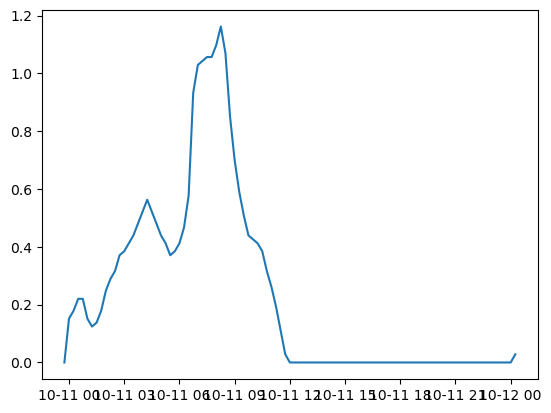

In [ ]:
fig, ax = plt.subplots()
ax.plot(t_riv,q_tj)
plt.yscale('linear')
print(t_riv[0],t_riv[-1])


In [16]:

unique_dates = set()
t_riv2 = np.array([dt.item() for dt in t_riv])

for dt_obj in t_riv2:
    unique_dates.add((dt_obj.year, dt_obj.month, dt_obj.day))

# Convert the set of tuples to a sorted list for consistent output
unique_list = sorted(list(unique_dates))
print(unique_list)

# Initialize an empty list to store datetime objects
datetime_list = []

# Iterate through the tuples and convert to datetime objects
for year, month, day in unique_list:
    dt_object = datetime(year, month, day)
    datetime_list.append(dt_object)

print(datetime_list)

datetime_array = np.array(datetime_list)
print(datetime_array)




[(2024, 10, 10), (2024, 10, 11), (2024, 10, 12)]
[datetime.datetime(2024, 10, 10, 0, 0), datetime.datetime(2024, 10, 11, 0, 0), datetime.datetime(2024, 10, 12, 0, 0)]
[datetime.datetime(2024, 10, 10, 0, 0)
 datetime.datetime(2024, 10, 11, 0, 0)
 datetime.datetime(2024, 10, 12, 0, 0)]


In [ ]:

datetime_array = np.array([f"{y}-{m:02d}-{d:02d}" for y, m, d in unique_list], dtype='datetime64[D]')
print(datetime_array)


In [ ]:
dum = 'nwm_assim_20241010.nc'
print(dum)
print(dum[-11:-3])


nwm_assim_20241010.nc
20241010


In [2]:
yyyymmdd='20241011'
t1 = datetime.strptime(yyyymmdd,'%Y%m%d')
t2 = t1 + 23 * timedelta(hours=1)

urls = riverfuns.get_hind_nwm_urls(t1,t2)



2024-10-11 00:00:00
2024-10-11 01:00:00
2024-10-11 02:00:00
2024-10-11 03:00:00
2024-10-11 04:00:00
2024-10-11 05:00:00
2024-10-11 06:00:00
2024-10-11 07:00:00
2024-10-11 08:00:00
2024-10-11 09:00:00
2024-10-11 10:00:00
2024-10-11 11:00:00
2024-10-11 12:00:00
2024-10-11 13:00:00
2024-10-11 14:00:00
2024-10-11 15:00:00
2024-10-11 16:00:00
2024-10-11 17:00:00
2024-10-11 18:00:00
2024-10-11 19:00:00
2024-10-11 20:00:00
2024-10-11 21:00:00
2024-10-11 22:00:00
2024-10-11 23:00:00


In [ ]:

reach_ids = [948070199, 20331702, 20324441]
            #SW         Otay      TJR 20324441 is last segment near ocean.
station_ids = np.array(['Sweewater','Otay','TJRE'])

reach_ids = np.array(reach_ids)
t, q, rids2 = riverfuns.get_nwm_assim_flow(urls,reach_ids)
# rivfuns sorts? the reach ids, therefore the new ording of the station ids is...
i1 = np.argsort(reach_ids)
i2 = np.argsort(rids2)
i3 = np.argsort(i2)
i0 = i1[i3]
names2 = station_ids[i0] # the correct order of the flow in array q.


['Sweewater' 'Otay' 'TJRE']


In [15]:
def mk_q_ncfile(t2,Q,rids,riv_names,file_name_out):
    # makes an nc file of discharge data for multiple rivers
    # fore_date is the start time of the forecast as datetime eg fore_date = datetime(2024,10,11)
    # t2 is the time stamps of the flow as an array of datetimes
    # Q is the nt by n_river np array of discharge
    # rids are the reach ids of the data
    # riv_name is a np array of strings that name each river.
    num_stations = len(riv_names)
    station_ids = riv_names

    with nc.Dataset(file_name_out, 'w', format='NETCDF4') as nc_file:
        # Create dimensions
        nc_file.createDimension('time', None)  # Unlimited dimension for time
        nc_file.createDimension('station', num_stations)

        # Create variables
        time_var = nc_file.createVariable('time', 'f8', ('time',))
        q_var = nc_file.createVariable('discharge', 'f8', ('time', 'station'))
        station_id_var = nc_file.createVariable('station_id', str, ('station',)) # For string station IDs
        reach_id_var = nc_file.createVariable('reach_id', int, ('station',)) # For string station IDs


        # Add attributes to variables (optional, but recommended for CF-compliance)
        time_var.units = 'days since 1999-01-01 00:00:00'
        time_var.calendar = 'gregorian'
        q_var.units = 'm^3/s'
        q_var.long_name = 'river discharge'
        station_id_var.long_name = 'river name'
        reach_id_var.long_name = 'reach ids from National Water Model'

        # Add global attributes (optional)
        nc_file.title = 'discharge from National Water Model'
        nc_file.history = f'Created on {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}'

        # 3. Write data to variables
        time_var[:] = nc.date2num(t2, units=time_var.units, calendar=time_var.calendar)
        q_var[:] = Q
        station_id_var[:] = station_ids
        reach_id_var[:] = rids


In [17]:
t_str = t[0].strftime('%Y%m%d')
file_name_out = '/dataSIO/PHM_Simulations/raw_download/nwm_files/NWM_assim_riverQ_'+t_str+'.nc'
mk_q_ncfile(t,q,rids2,names2,file_name_out)



In [18]:
ds = nc.Dataset(file_name_out)
print(ds)
print(ds.variables['time'][:])
print(ds.variables['discharge'][:])
print(ds.variables['reach_id'][:])
print(ds.variables['station_id'][:])


<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    title: discharge from National Water Model
    history: Created on 2025-09-08 14:16:14
    dimensions(sizes): time(24), station(3)
    variables(dimensions): float64 time(time), float64 discharge(time, station), <class 'str'> station_id(station), int64 reach_id(station)
    groups: 
[9415.         9415.04166667 9415.08333333 9415.125      9415.16666667
 9415.20833333 9415.25       9415.29166667 9415.33333333 9415.375
 9415.41666667 9415.45833333 9415.5        9415.54166667 9415.58333333
 9415.625      9415.66666667 9415.70833333 9415.75       9415.79166667
 9415.83333333 9415.875      9415.91666667 9415.95833333]
[[0.49999999 1.37999997 2.21999995]
 [0.49999999 1.37999997 2.21999995]
 [0.49999999 1.37999997 2.21999995]
 [0.49999999 1.37999997 2.21999995]
 [0.49999999 1.37999997 2.21999995]
 [0.49999999 1.37999997 2.21999995]
 [0.49999999 1.37999997 2.21999995]
 [0.49999999 1.37999997 2.21999995]
 [0.499999

In [9]:

i1 = np.argsort(reach_ids)
i2 = np.argsort(rids2)
i3 = np.argsort(i2)
i0 = i1[i3]
names2 = station_ids[i0]
print(reach_ids)
print(rids2[:])
print(reach_ids[i0])
print(i1)
print(i2)
print(i3)
print(i0)
print(station_ids)
print(names2)

print(q[0:5,:])




[948070199  20331702  20324441]
[ 20324441  20331702 948070199]
[ 20324441  20331702 948070199]
[2 1 0]
[0 1 2]
[0 1 2]
[2 1 0]
['Sweewater' 'Otay' 'TJRE']
['TJRE' 'Otay' 'Sweewater']
[[0.49999999 1.37999997 2.21999995]
 [0.49999999 1.37999997 2.21999995]
 [0.49999999 1.37999997 2.21999995]
 [0.49999999 1.37999997 2.21999995]
 [0.49999999 1.37999997 2.21999995]]


In [ ]:
print(np.shape(t))
print(np.shape(q))
print(t)
print(q)


In [20]:
arr1 = np.array([3, 2, 4, 1])
arr2 = np.array([2, 1, 4, 3])

# Get the indices that would sort arr1
i1 = np.argsort(arr1)

# Get the indices that would sort arr2
i2 = np.argsort(arr2)

# Create a mapping from sorted arr1 to sorted arr2
# This assumes the values are the same, just in a different order
#mapping_indices = sort_indices_arr1[np.argsort(arr2[sort_indices_arr1])]
i0 = i1[np.argsort(i2)]


print(f"Original array 1: {arr1}")
print(i1)
print(f"Original array 2: {arr2}")
print(i2)
print(f"Indices to transform arr1 to arr2: {i0}")
# Verify the transformation
print(f"Transformed arr1: {arr1[i0]}")

Original array 1: [3 2 4 1]
[3 1 0 2]
Original array 2: [2 1 4 3]
[1 0 3 2]
Indices to transform arr1 to arr2: [1 3 2 0]
Transformed arr1: [2 1 4 3]


In [4]:
test_file_full = '/home/mspydell/test_file.txt'
test_file_new_dir = '/home/mspydell/research/'
test_file_new_dir2 = test_file_new_dir[0:-1]
print(test_file_new_dir2)
shutil.copy(test_file_full,test_file_new_dir2)
    


/home/mspydell/research


'/home/mspydell/research/test_file.txt'

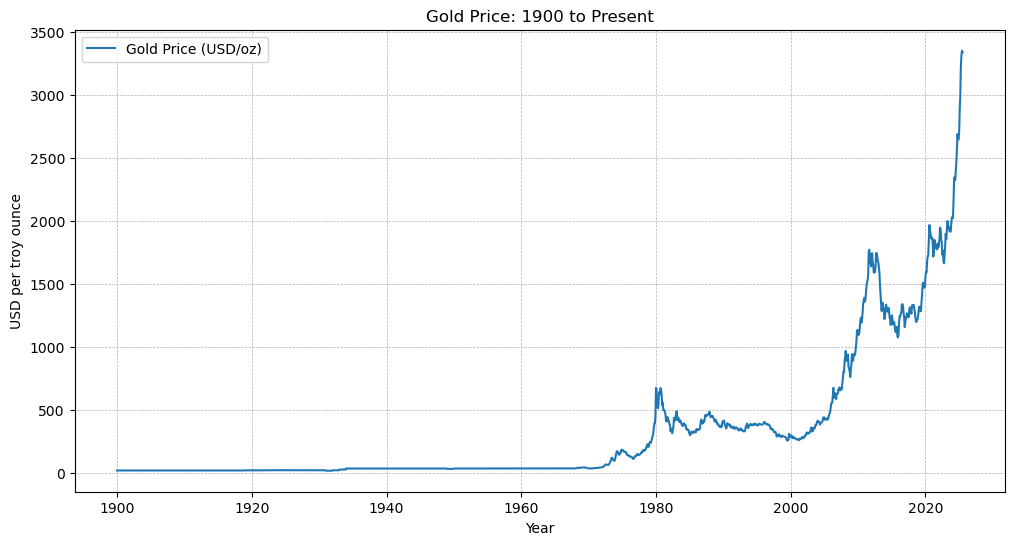

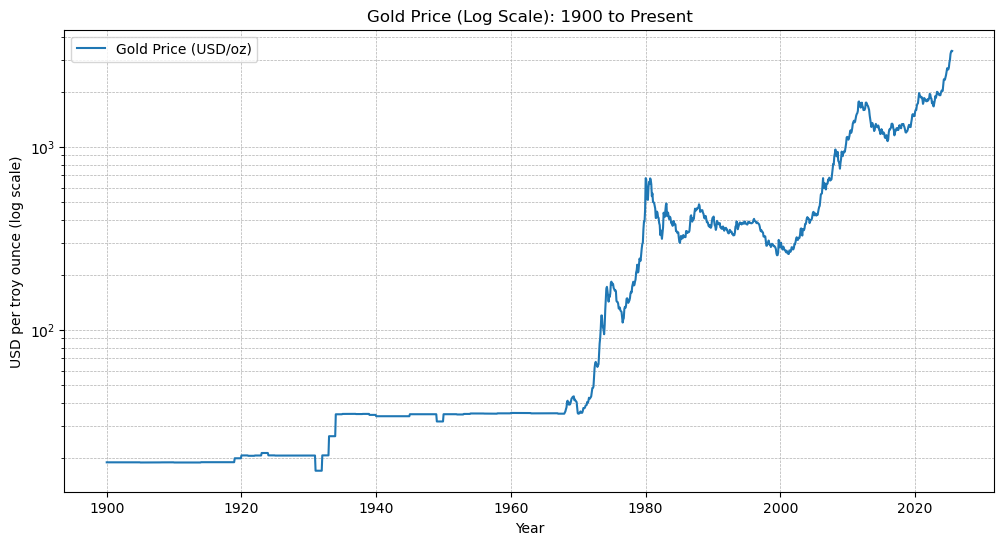

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load gold price data from DataHub
url = "https://datahub.io/core/gold-prices/r/monthly.csv"
df = pd.read_csv(url, parse_dates=['Date'])

# The DataHub dataset uses “Price” column in USD per troy ounce
df.rename(columns={"Price": "Gold_USD"}, inplace=True)

# If you want to restrict to 1900 onward:
df = df[df['Date'].dt.year >= 1900]

# Plot gold price (linear and log scales)
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Gold_USD'], label='Gold Price (USD/oz)')
plt.title('Gold Price: 1900 to Present')
plt.xlabel('Year')
plt.ylabel('USD per troy ounce')
plt.grid(True, ls='--', lw=0.5)
plt.legend()
plt.show()

# Also a log-scale version
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Gold_USD'], label='Gold Price (USD/oz)')
plt.yscale('log')
plt.title('Gold Price (Log Scale): 1900 to Present')
plt.xlabel('Year')
plt.ylabel('USD per troy ounce (log scale)')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.legend()
plt.show()
